## This is the code for generating Feature Heatmap plot.

By default, if you play this file directly, it will generate the Feature Heatmap plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Compute the pairwise weighted Kendall tau matrix -> Turn the Matrix into the corresponding heatmap

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Feature Heatmap Plot 

You don't need to change anything else if you only want to produce the Heatmap plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [1]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

# Influence Ranking Read-In Area

Again, change here for your desired influence lists.

In [2]:
IF_1 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_00.csv")
IF_2 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_10.csv")
IF_3 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_14.csv")
IF_4 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_18.csv")
IF_5 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_22.csv")
IF_6 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_26.csv")
IF_7 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_30.csv")
IF_8 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_34.csv")
IF_9 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_38.csv")
IF_10 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_42.csv")

TC_1 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_00.csv")
TC_2 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_10.csv")
TC_3 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_14.csv")
TC_4 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_18.csv")
TC_5 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_22.csv")
TC_6 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_26.csv")
TC_7 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_30.csv")
TC_8 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_34.csv")
TC_9 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_38.csv")
TC_10 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_42.csv")

In [3]:
sorted_IF_lists = [IF_1, IF_2,IF_3,IF_4,IF_5,IF_6,IF_7,IF_8,IF_9,IF_10]
sorted_TC_lists = [TC_1, TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,TC_10]
Train_Size = [10,20,24,28,32,36,40,44,48,52]

1. Here we initial the weighted kendall tau matrix.

In [4]:
num_lists = len(sorted_IF_lists)

In [5]:
tau_matrix_TC = np.full((num_lists, num_lists), np.nan)
tau_matrix_IF = np.full((num_lists, num_lists), np.nan)
print(tau_matrix_IF)

[[nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]]


2. Here we compute the pairwise weighted kendall tau value for all the Influence Function's ranked influence lists.

In [6]:
for i in range(num_lists):
    tau_matrix_IF[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_IF_lists[i]
        df2 = sorted_IF_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                        weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_IF[i, j] = wt
        tau_matrix_IF[j, i] = wt

print(tau_matrix_IF)

[[1.         0.68510582 0.64874415 0.60723131 0.5803788  0.56371172
  0.56654371 0.54691994 0.53296403 0.52631246]
 [0.68510582 1.         0.80100676 0.72480347 0.68434727 0.66091309
  0.65387718 0.63385909 0.62832983 0.61009098]
 [0.64874415 0.80100676 1.         0.78354018 0.73215571 0.69772765
  0.68467966 0.66868478 0.65833631 0.64318   ]
 [0.60723131 0.72480347 0.78354018 1.         0.82637483 0.77777178
  0.75092806 0.72851621 0.71301279 0.6949807 ]
 [0.5803788  0.68434727 0.73215571 0.82637483 1.         0.82989505
  0.78487057 0.76091954 0.7385229  0.72060412]
 [0.56371172 0.66091309 0.69772765 0.77777178 0.82989505 1.
  0.84594962 0.79525932 0.77093174 0.74937414]
 [0.56654371 0.65387718 0.68467966 0.75092806 0.78487057 0.84594962
  1.         0.83574763 0.79727353 0.77322969]
 [0.54691994 0.63385909 0.66868478 0.72851621 0.76091954 0.79525932
  0.83574763 1.         0.84133515 0.80174707]
 [0.53296403 0.62832983 0.65833631 0.71301279 0.7385229  0.77093174
  0.79727353 0.84133

3. Here we compute the pairwise weighted kendall tau value for all the TracIn's ranked influence lists.

In [7]:
for i in range(num_lists):
    tau_matrix_TC[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_TC_lists[i]
        df2 = sorted_TC_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                         weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_TC[i, j] = wt
        tau_matrix_TC[j, i] = wt

print(tau_matrix_TC)

[[1.         0.87240922 0.84800195 0.84816274 0.84180071 0.83801943
  0.83071845 0.81983008 0.81567327 0.81092603]
 [0.87240922 1.         0.91749782 0.89327416 0.87630855 0.86786317
  0.85820636 0.85117873 0.848801   0.83897386]
 [0.84800195 0.91749782 1.         0.91719728 0.89606538 0.88405001
  0.86992142 0.86790246 0.86525203 0.85485005]
 [0.84816274 0.89327416 0.91719728 1.         0.93438948 0.91682183
  0.89700684 0.89050855 0.8861957  0.87621093]
 [0.84180071 0.87630855 0.89606538 0.93438948 1.         0.9363037
  0.91076117 0.9025694  0.89645971 0.88419689]
 [0.83801943 0.86786317 0.88405001 0.91682183 0.9363037  1.
  0.93717839 0.91825034 0.90670979 0.89566   ]
 [0.83071845 0.85820636 0.86992142 0.89700684 0.91076117 0.93717839
  1.         0.93439284 0.91334829 0.90009133]
 [0.81983008 0.85117873 0.86790246 0.89050855 0.9025694  0.91825034
  0.93439284 1.         0.93756733 0.91890483]
 [0.81567327 0.848801   0.86525203 0.8861957  0.89645971 0.90670979
  0.91334829 0.937567

4. Now we turn each weighted tau matrix into a triangular heatmap. This is to remove the duplicate half.

In [8]:
labels = [f"Run {idx+1}\Size={size:}" for idx, size in enumerate(Train_Size)]
df_tau_IF = pd.DataFrame(tau_matrix_IF, index=labels, columns=labels)
df_tau_TC = pd.DataFrame(tau_matrix_TC, index=labels, columns=labels)

In [9]:
mask_lower = np.triu(np.ones_like(tau_matrix_IF, dtype=bool), k=1)
triangular_IF = tau_matrix_IF.copy()
triangular_IF[mask_lower] = np.nan
triangular_TC = tau_matrix_TC.copy()
triangular_TC[mask_lower] = np.nan

print(mask_lower)

[[False  True  True  True  True  True  True  True  True  True]
 [False False  True  True  True  True  True  True  True  True]
 [False False False  True  True  True  True  True  True  True]
 [False False False False  True  True  True  True  True  True]
 [False False False False False  True  True  True  True  True]
 [False False False False False False  True  True  True  True]
 [False False False False False False False  True  True  True]
 [False False False False False False False False  True  True]
 [False False False False False False False False False  True]
 [False False False False False False False False False False]]


IF

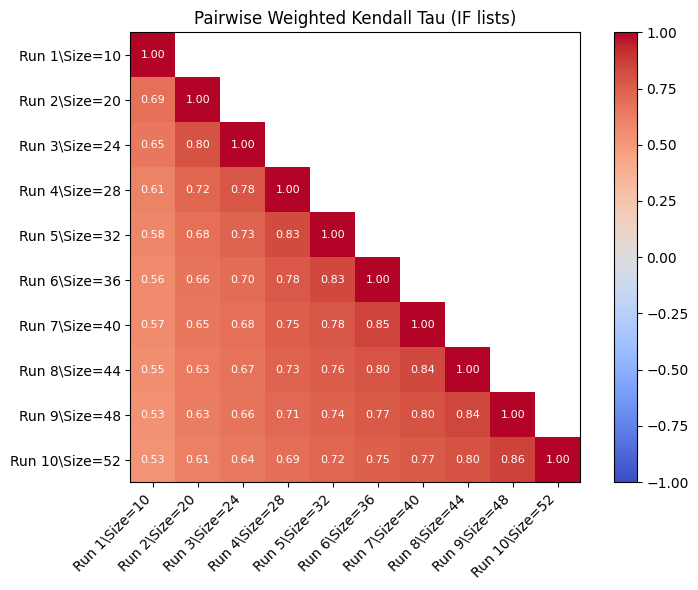

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_IF, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Pairwise Weighted Kendall Tau (IF lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels)

rows, cols = np.where(~np.isnan(triangular_IF))
for i, j in zip(rows, cols):
    val = triangular_IF[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()

TC

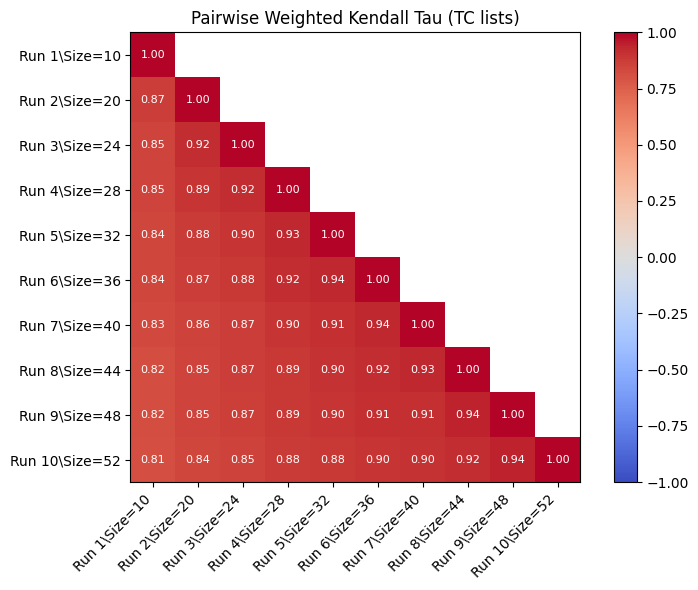

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_TC, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Pairwise Weighted Kendall Tau (TC lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels)

rows, cols = np.where(~np.isnan(triangular_TC))
for i, j in zip(rows, cols):
    val = triangular_TC[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()